ILP in Real Time Scheduling: Traffic Management for Autonomous Vehicles 
3 by 3 grid intersections
Ekene Okeke and Kadhana Penumaka

In [1]:
!pip install numpy pandas matplotlib pulp


   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   -------------- ------------------------- 6.0/16.4 MB 33.5 MB/s eta 0:00:01
   ---------------------------------------  16.3/16.4 MB 46.5 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 41.3 MB/s eta 0:00:00


In [2]:
# add import statments
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpStatus, value
import matplotlib.patches as mpatches

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpStatus, value

In [3]:
# to generate repeatable results for explaination in the report
random.seed(42)
np.random.seed(42)

# parameters for our model
intersection_length = 10  # this is the length of the intersection in 
n_vehicles = 9
v_avg_mean = 5  # m/s
v_avg_std = 0.5  # m/s

# generate vehicles
v_avgs = np.clip(np.random.normal(v_avg_mean, v_avg_std, n_vehicles), 1, None)
vehicle_ids = list(range(1, n_vehicles + 1))
desired_access_times = intersection_length / v_avgs

# Phase assignment
phase_cycle = ["X'", "X''", "O'", "O''"]
phases = [phase_cycle[i % len(phase_cycle)] for i in range(n_vehicles)]

vehicles_df = pd.DataFrame({
    "vehicle_id": vehicle_ids,
    "v_avg": v_avgs,
    "desired_access_time": desired_access_times,
    "phase": phases
})

print("\nVehicles that have been randomly generated:")
print(vehicles_df)

grid_size = 3
travel_time_between_intersections = 1.0  
current_entry_times = desired_access_times.copy()
full_results = {}

# MILP parameters
w1 = 1.0
w2 = 1.0
t_gap1 = 1.0
t_gap2 = 2.0
big_M  = 1000.0



Vehicles that have been randomly generated:
   vehicle_id     v_avg  desired_access_time phase
0           1  5.248357             1.905358    X'
1           2  4.930868             2.028041   X''
2           3  5.323844             1.878342    O'
3           4  5.761515             1.735655   O''
4           5  4.882923             2.047954    X'
5           6  4.882932             2.047950   X''
6           7  5.789606             1.727233    O'
7           8  5.383717             1.857453   O''
8           9  4.765263             2.098520    X'


In [4]:
# Distributed MILP across grid
for row in range(1, grid_size + 1):
    for col in range(1, grid_size + 1):
        prob = LpProblem(f"Access_Time_Optimization_I{row}_{col}", LpMinimize)
        
        # access-time decision variables
        t_access = {
            vid: LpVariable(f"t_access_I{row}_{col}_v{vid}", lowBound=0)
            for vid in vehicle_ids
        }
        
       
        for i in range(n_vehicles):
            for j in range(i+1, n_vehicles):
                vid_i = vehicle_ids[i]
                vid_j = vehicle_ids[j]
                if vehicles_df.loc[i, "phase"] == vehicles_df.loc[j, "phase"]:
                    # enforce that the later‐indexed vehicle enters at least t_gap1 after the earlier
                    prob += t_access[vid_j] >= t_access[vid_i] + t_gap1, \
                            f"SameGap_{vid_i}_{vid_j}_I{row}_{col}"
                    

      
        for i in range(2, n_vehicles + 1):
            prob += t_access[i] >= t_access[i-1], f"Order_{i}_I{row}_{col}"
        
        #phase-conflict 
        for i in range(n_vehicles):
            for j in range(i+1, n_vehicles):
                vid_i = vehicle_ids[i]
                vid_j = vehicle_ids[j]
                if vehicles_df.loc[i, "phase"] != vehicles_df.loc[j, "phase"]:
                    y = LpVariable(f"y_{vid_i}_{vid_j}_I{row}_{col}", cat="Binary")
                    prob += (
                        t_access[vid_j] >= t_access[vid_i] + t_gap2
                        - big_M * (1 - y),
                        f"Conf1_{vid_i}_{vid_j}_I{row}_{col}"
                    )
                    prob += (
                        t_access[vid_i] >= t_access[vid_j] + t_gap2
                        - big_M * y,
                        f"Conf2_{vid_i}_{vid_j}_I{row}_{col}"
                    )
        
        # difference for J2
        delta = {
            vid: LpVariable(f"delta_I{row}_{col}_v{vid}", lowBound=0)
            for vid in vehicle_ids
        }
        for idx, vid in enumerate(vehicle_ids):
            ent = current_entry_times[idx]
            prob += t_access[vid] - ent <= delta[vid], f"DeltaUp_{vid}_I{row}_{col}"
            prob += ent - t_access[vid] <= delta[vid], f"DeltaDn_{vid}_I{row}_{col}"
        
        # 5) objective
        J1 = t_access[max(vehicle_ids)] - t_access[min(vehicle_ids)]
        J2 = lpSum(delta.values())
        prob += w1 * J1 + w2 * J2, f"TotalCost_I{row}_{col}"
        
      
        prob.solve()
        print(f"I({row},{col}) status:", LpStatus[prob.status])
        
     
        opt = [value(t_access[vid]) for vid in vehicle_ids]
        diff = np.array(opt) - np.array(current_entry_times)
        df = vehicles_df.copy()
        df[f"optimized_access_time_I{row}_{col}"] = opt
        df[f"difference_I{row}_{col}"] = diff
        full_results[(row, col)] = df
        
         # update for next intersection
        exits = [opt[i] + intersection_length / v_avgs[i] for i in range(n_vehicles)]
        current_entry_times = np.array(exits) + travel_time_between_intersections

I(1,1) status: Optimal
I(1,2) status: Optimal
I(1,3) status: Optimal
I(2,1) status: Optimal
I(2,2) status: Optimal
I(2,3) status: Optimal
I(3,1) status: Optimal
I(3,2) status: Optimal
I(3,3) status: Optimal


Plot Line graph for all intersections

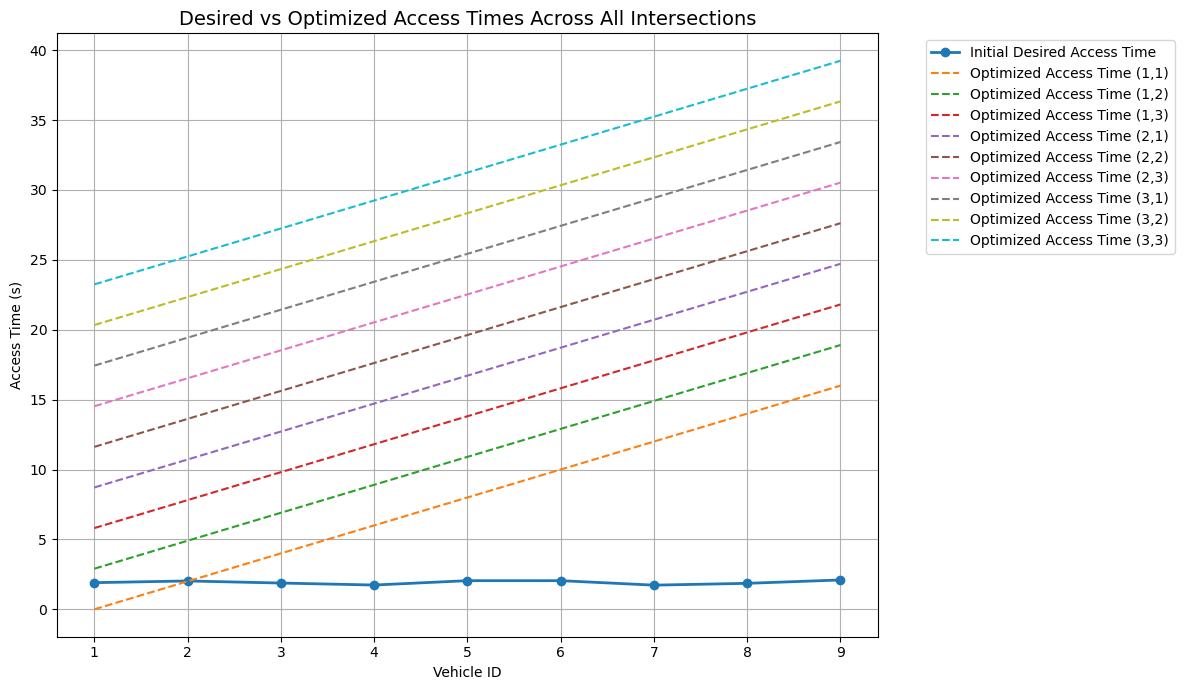

In [5]:
# Plot the line graph of all the intersections 

fig, ax = plt.subplots(figsize=(12, 7))


ax.plot(vehicles_df["vehicle_id"], vehicles_df["desired_access_time"], 'o-', label="Initial Desired Access Time", linewidth=2)


for row in range(1, grid_size + 1):
    for col in range(1, grid_size + 1):
        result_df = full_results[(row, col)]
        label = f"Optimized Access Time ({row},{col})"
        ax.plot(result_df["vehicle_id"], result_df[f"optimized_access_time_I{row}_{col}"], '--', label=label)

ax.set_xlabel("Vehicle ID")
ax.set_ylabel("Access Time (s)")
ax.set_title("Desired vs Optimized Access Times Across All Intersections", fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()



Gantt Graph for all the intersections

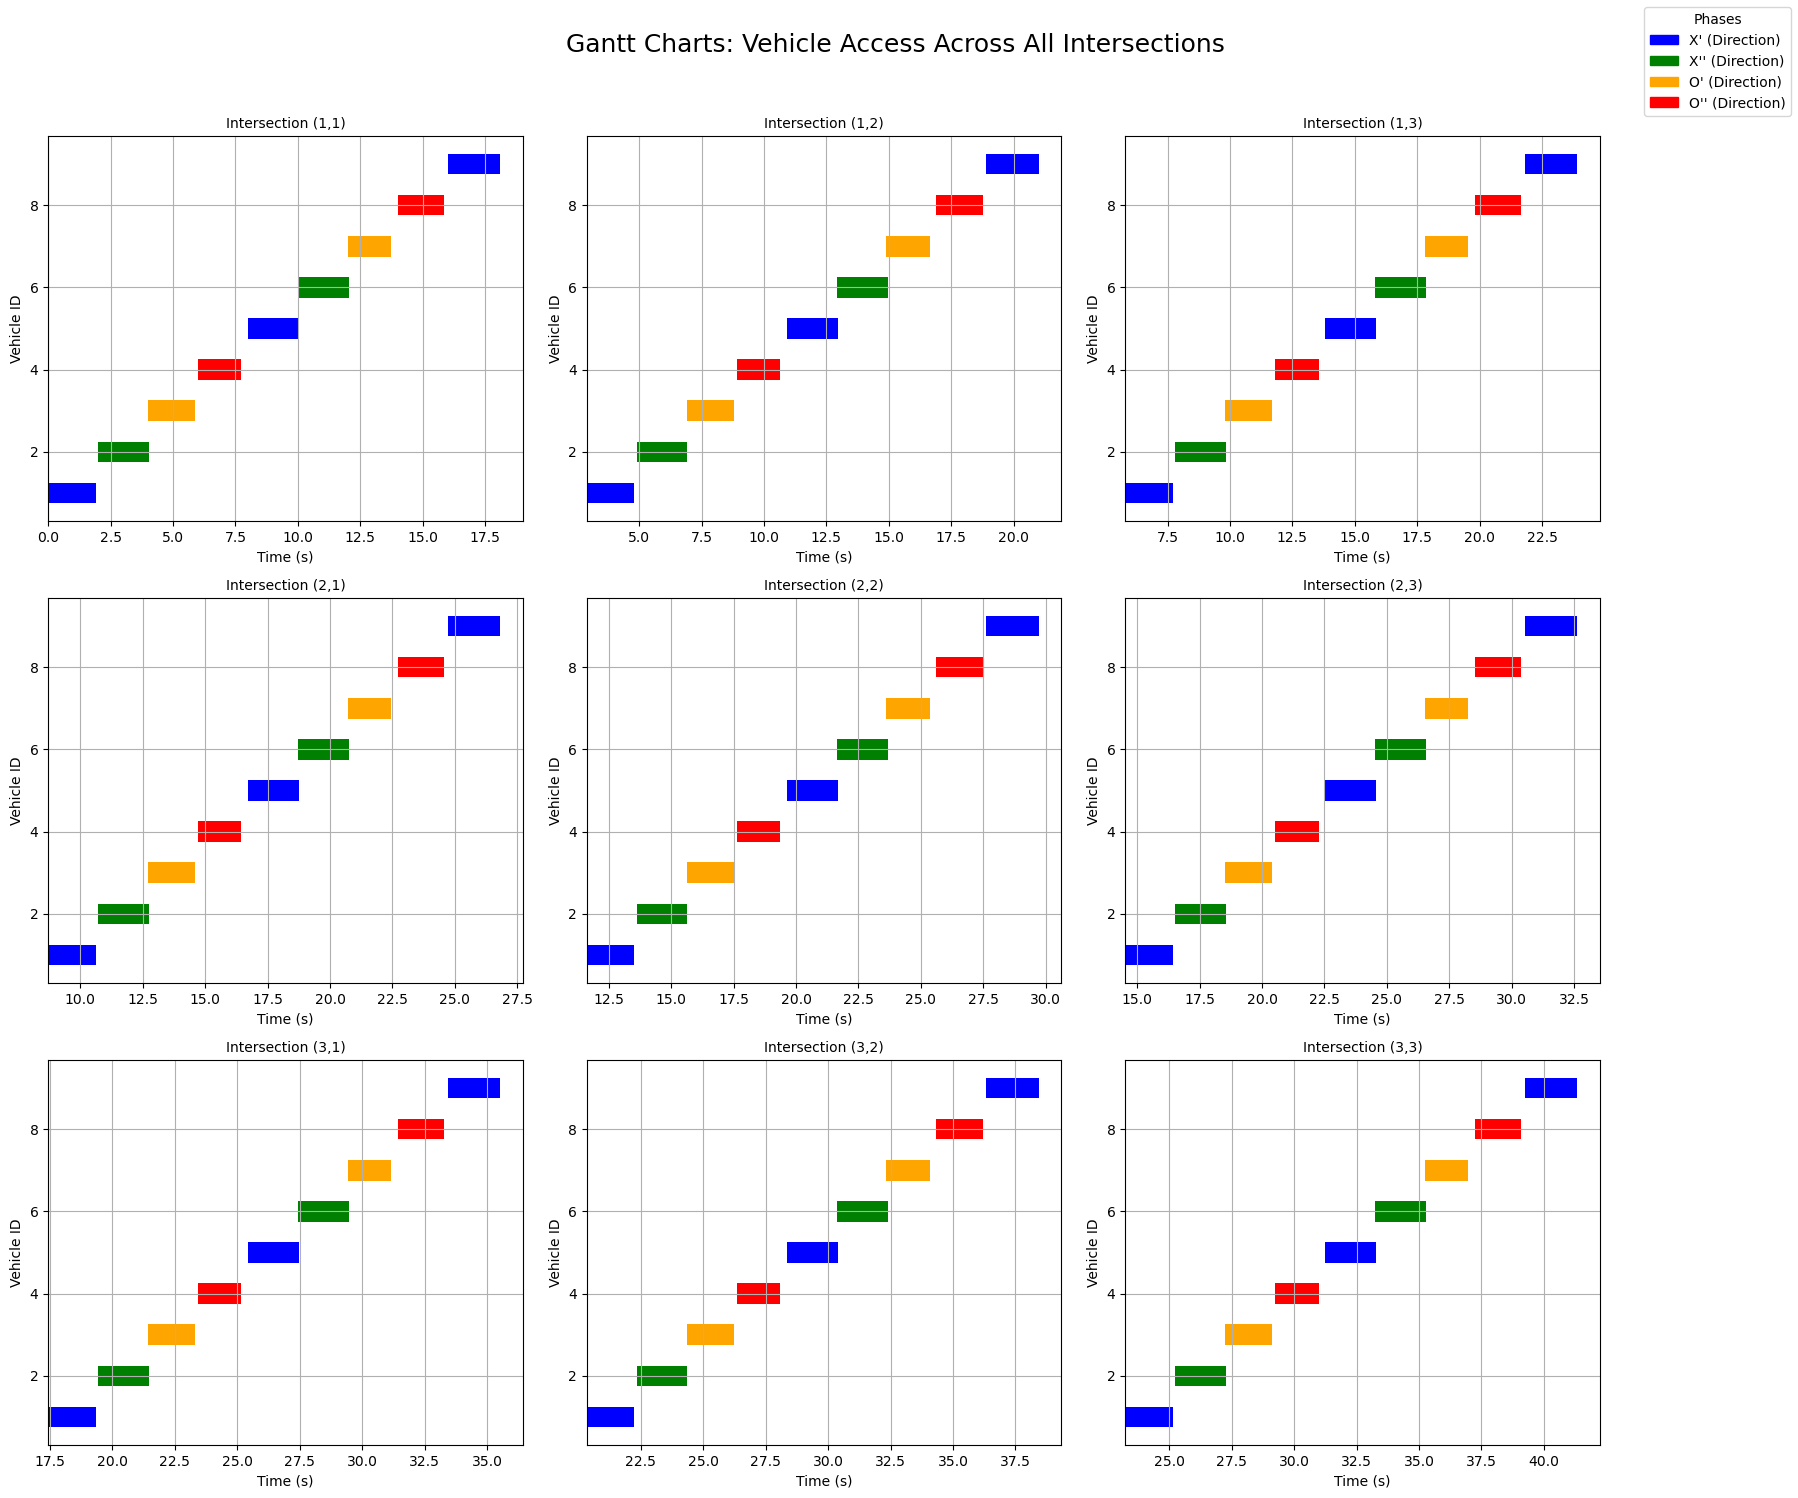

In [6]:
#Ganntt graph that shows the cars moving through the intersections
import matplotlib.patches as mpatches
# Colors for each phases is as follows :
phase_colors = {
    "X'": "blue",      # Southbound
    "X''": "green",    # Northbound
    "O'": "orange",    # Westbound
    "O''": "red",      # Eastbound
}

fig, axes = plt.subplots(grid_size, grid_size, figsize=(18, 15), sharex=False, sharey=False)
fig.suptitle("Gantt Charts: Vehicle Access Across All Intersections", fontsize=18)

for row in range(1, grid_size + 1):
    for col in range(1, grid_size + 1):
        ax = axes[row - 1, col - 1]
        intersection_plot = full_results[(row, col)]

        for idx, r in intersection_plot.iterrows():
            start_time = r[f"optimized_access_time_I{row}_{col}"]
            duration = intersection_length / r["v_avg"]
            phase = r["phase"]
            color = phase_colors.get(phase, "gray")

            ax.barh(r["vehicle_id"], duration, left=start_time, height=0.5, color=color)

        ax.set_title(f"Intersection ({row},{col})", fontsize=10)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Vehicle ID")
        ax.grid(True)


handles = [mpatches.Patch(color=color, label=f"{phase} (Direction)") for phase, color in phase_colors.items()]
fig.legend(handles=handles, title="Phases", loc='upper right')

plt.tight_layout(rect=[0, 0, 0.9, 0.96])  
plt.savefig("gantt_all_intersections.png", dpi=300)
plt.show()